# RiNALMo findability deep-dive

Can you find one ncRNA by sliding through a long embedding containing a
*different member of the same family*? This is the real pipeline use case:
reference and query are similar but not identical.

Test pairs: tRNA-Asn, tRNA-Ala, miRNA MIR103A, snoRNA SNORA2.

In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "modules" / "RiNALMo"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))

import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

SEED = 42
random.seed(SEED); np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

# Load RiNALMo
from rinalmo.pretrained import get_pretrained_model
rin_model, rin_alpha = get_pretrained_model(model_name="giga-v1")
rin_model = rin_model.to(device).eval()

def emb(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    tokens = torch.tensor(
        rin_alpha.batch_tokenize([rna]), dtype=torch.int64, device=device
    )
    with torch.no_grad():
        out = rin_model(tokens)
    return out["representation"][0, 1:1 + len(rna), :].cpu().float().numpy()

print(f"RiNALMo loaded on {device}")

RiNALMo loaded on mps


## Extract test pairs with genomic flanks

In [2]:
BED_PATH    = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
TWOBIT_PATH = REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"

accessor = TwoBitAccessor(str(TWOBIT_PATH))
bed_data = read_bed12_file(str(BED_PATH))
tx_lookup = {t.id: t for t in bed_data}

# Define test pairs
PAIRS = [
    {"name": "tRNA-Asn", "class": "tRNA",
     "a": "tRNA-Asn-GTT-chr1-140", "b": "tRNA-Asn-GTT-chr1-139"},
    {"name": "tRNA-Ala", "class": "tRNA",
     "a": "tRNA-Ala-AGC-12-1", "b": "tRNA-Ala-AGC-12-2"},
    {"name": "MIR103A", "class": "miRNA",
     "a": "ENST00000362168.1", "b": "ENST00000362154.1"},
    {"name": "SNORA2", "class": "snoRNA",
     "a": "ENST00000383885.1", "b": "ENST00000408564.2"},
]

MAX_FLANK = 150

def get_seq_with_flanks(tid):
    """Return (core_seq, left_flank, right_flank) for a transcript."""
    t = tx_lookup[tid]
    core = sn._get_spliced_sequence(t, accessor).upper().replace("T", "U")
    comp = {"A": "U", "T": "A", "G": "C", "C": "G", "N": "N"}
    if t.strand >= 0:
        lf = str(accessor.fetch(t.chrom, max(0, t.start - MAX_FLANK), t.start)).upper().replace("T", "U")
        rf = str(accessor.fetch(t.chrom, t.end, t.end + MAX_FLANK)).upper().replace("T", "U")
    else:
        right_raw = str(accessor.fetch(t.chrom, t.end, t.end + MAX_FLANK)).upper()
        left_raw = str(accessor.fetch(t.chrom, max(0, t.start - MAX_FLANK), t.start)).upper()
        lf = "".join(comp.get(b, "N") for b in reversed(right_raw))
        rf = "".join(comp.get(b, "N") for b in reversed(left_raw))
    return core, lf, rf

# Extract all sequences
pair_data = []
for p in PAIRS:
    a_core, a_lf, a_rf = get_seq_with_flanks(p["a"])
    b_core, b_lf, b_rf = get_seq_with_flanks(p["b"])
    pair_data.append({
        **p,
        "a_core": a_core, "a_lf": a_lf, "a_rf": a_rf,
        "b_core": b_core, "b_lf": b_lf, "b_rf": b_rf,
    })
    print(f"{p['name']:>10s}: A={len(a_core)} nt, B={len(b_core)} nt  "
          f"(flanks: L={len(a_lf)}/{len(b_lf)}, R={len(a_rf)}/{len(b_rf)})")

print(f"\n{len(pair_data)} pairs loaded")

  tRNA-Asn: A=74 nt, B=74 nt  (flanks: L=150/150, R=150/150)
  tRNA-Ala: A=73 nt, B=73 nt  (flanks: L=150/150, R=150/150)
   MIR103A: A=110 nt, B=78 nt  (flanks: L=150/150, R=150/150)
    SNORA2: A=135 nt, B=137 nt  (flanks: L=150/150, R=150/150)

4 pairs loaded


## Baseline MMD: standalone embeddings

For each pair, compute MMD(A, B) with both embedded standalone.
Also compute MMD to a random genomic window as negative control.

In [3]:
# Generate a random noise sequence for negative control
rng = random.Random(SEED)
noise_seq = "".join(rng.choices("AUGC", k=74))
noise_emb = emb(noise_seq)

baseline_rows = []
for p in pair_data:
    emb_a = emb(p["a_core"])
    emb_b = emb(p["b_core"])
    mmd_ab = sn._compute_mmd(emb_a, emb_b)
    mmd_a_noise = sn._compute_mmd(emb_a, noise_emb)
    mmd_b_noise = sn._compute_mmd(emb_b, noise_emb)
    baseline_rows.append({
        "pair": p["name"], "class": p["class"],
        "len_A": len(p["a_core"]), "len_B": len(p["b_core"]),
        "MMD(A,B)": mmd_ab,
        "MMD(A,noise)": mmd_a_noise,
        "MMD(B,noise)": mmd_b_noise,
    })
    print(f"{p['name']:>10s}: MMD(A,B)={mmd_ab:.4f}  "
          f"MMD(A,noise)={mmd_a_noise:.4f}  MMD(B,noise)={mmd_b_noise:.4f}")

baseline_df = pd.DataFrame(baseline_rows)
print("\n" + baseline_df.to_string(index=False))

  tRNA-Asn: MMD(A,B)=0.0000  MMD(A,noise)=0.2464  MMD(B,noise)=0.2406
  tRNA-Ala: MMD(A,B)=0.0000  MMD(A,noise)=0.2108  MMD(B,noise)=0.2108
   MIR103A: MMD(A,B)=0.0910  MMD(A,noise)=0.1145  MMD(B,noise)=0.1509
    SNORA2: MMD(A,B)=0.0000  MMD(A,noise)=0.1590  MMD(B,noise)=0.1539

    pair  class  len_A  len_B  MMD(A,B)  MMD(A,noise)  MMD(B,noise)
tRNA-Asn   tRNA     74     74  0.000000      0.246402      0.240602
tRNA-Ala   tRNA     73     73  0.000000      0.210836      0.210836
 MIR103A  miRNA    110     78  0.091018      0.114537      0.150941
  SNORA2 snoRNA    135    137  0.000000      0.159039      0.153874


## Findability: slide reference A through flanked B

For each pair: embed A standalone (reference), embed B with flanking context.
Slide an A-length window through B's long embedding. Does the MMD minimum
land at the correct position?

In [4]:
FLANK_SIZES = [20, 50, 100, 150]

def slide_find(ref_emb, long_emb, window_len, true_start):
    """Slide ref-length window through long_emb, return MMD profile + best pos."""
    n = len(long_emb) - window_len + 1
    profile = np.zeros(n)
    for i in range(n):
        profile[i] = sn._compute_mmd(ref_emb, long_emb[i:i + window_len])
    best = int(np.argmin(profile))
    return profile, best, best - true_start

find_rows = []
find_profiles = {}  # (pair_name, flank) -> profile

for p in pair_data:
    ref_emb = emb(p["a_core"])  # reference: member A standalone
    ref_len = len(p["a_core"])
    print(f"\n=== {p['name']} (ref A={ref_len} nt) ===")

    for f in FLANK_SIZES:
        # Build flanked B
        lf = p["b_lf"][-f:] if f <= len(p["b_lf"]) else p["b_lf"]
        rf = p["b_rf"][:f] if f <= len(p["b_rf"]) else p["b_rf"]
        flanked_b = lf + p["b_core"] + rf
        true_start = len(lf)

        # Embed flanked B once
        long_emb = emb(flanked_b)

        # Slide
        profile, best_pos, offset = slide_find(ref_emb, long_emb, ref_len, true_start)

        mmd_at_true = profile[true_start] if true_start < len(profile) else float("nan")
        mmd_at_best = profile[best_pos]
        # Noise floor: median MMD in the flanking regions
        flank_mmds = np.concatenate([profile[:max(1, true_start-5)],
                                      profile[min(len(profile), true_start+ref_len+5):]])
        noise_floor = np.median(flank_mmds) if len(flank_mmds) > 0 else float("nan")

        find_rows.append({
            "pair": p["name"], "class": p["class"], "flank": f,
            "true_start": true_start, "found_pos": best_pos, "offset": offset,
            "mmd_best": mmd_at_best, "mmd_true": mmd_at_true,
            "noise_floor": noise_floor,
        })
        find_profiles[(p["name"], f)] = profile

        status = "OK" if abs(offset) <= 5 else f"OFF by {abs(offset)}"
        print(f"  flank={f:>3d}: found={best_pos}, true={true_start}, "
              f"off={offset:+d} [{status}]  MMD={mmd_at_best:.4f}  noise={noise_floor:.4f}")

find_df = pd.DataFrame(find_rows)


=== tRNA-Asn (ref A=74 nt) ===
  flank= 20: found=16, true=20, off=-4 [OK]  MMD=0.0000  noise=0.0596
  flank= 50: found=48, true=50, off=-2 [OK]  MMD=0.0470  noise=0.1297
  flank=100: found=95, true=100, off=-5 [OK]  MMD=0.0907  noise=0.1472
  flank=150: found=147, true=150, off=-3 [OK]  MMD=0.0929  noise=0.1574

=== tRNA-Ala (ref A=73 nt) ===
  flank= 20: found=8, true=20, off=-12 [OFF by 12]  MMD=0.0000  noise=0.0266
  flank= 50: found=39, true=50, off=-11 [OFF by 11]  MMD=0.0000  noise=0.1009
  flank=100: found=89, true=100, off=-11 [OFF by 11]  MMD=0.0000  noise=0.1632
  flank=150: found=139, true=150, off=-11 [OFF by 11]  MMD=0.0000  noise=0.1826

=== MIR103A (ref A=110 nt) ===
  flank= 20: found=0, true=20, off=-20 [OFF by 20]  MMD=0.0761  noise=0.0789
  flank= 50: found=21, true=50, off=-29 [OFF by 29]  MMD=0.0690  noise=0.0822
  flank=100: found=60, true=100, off=-40 [OFF by 40]  MMD=0.0819  noise=0.0909
  flank=150: found=121, true=150, off=-29 [OFF by 29]  MMD=0.0879  noise=

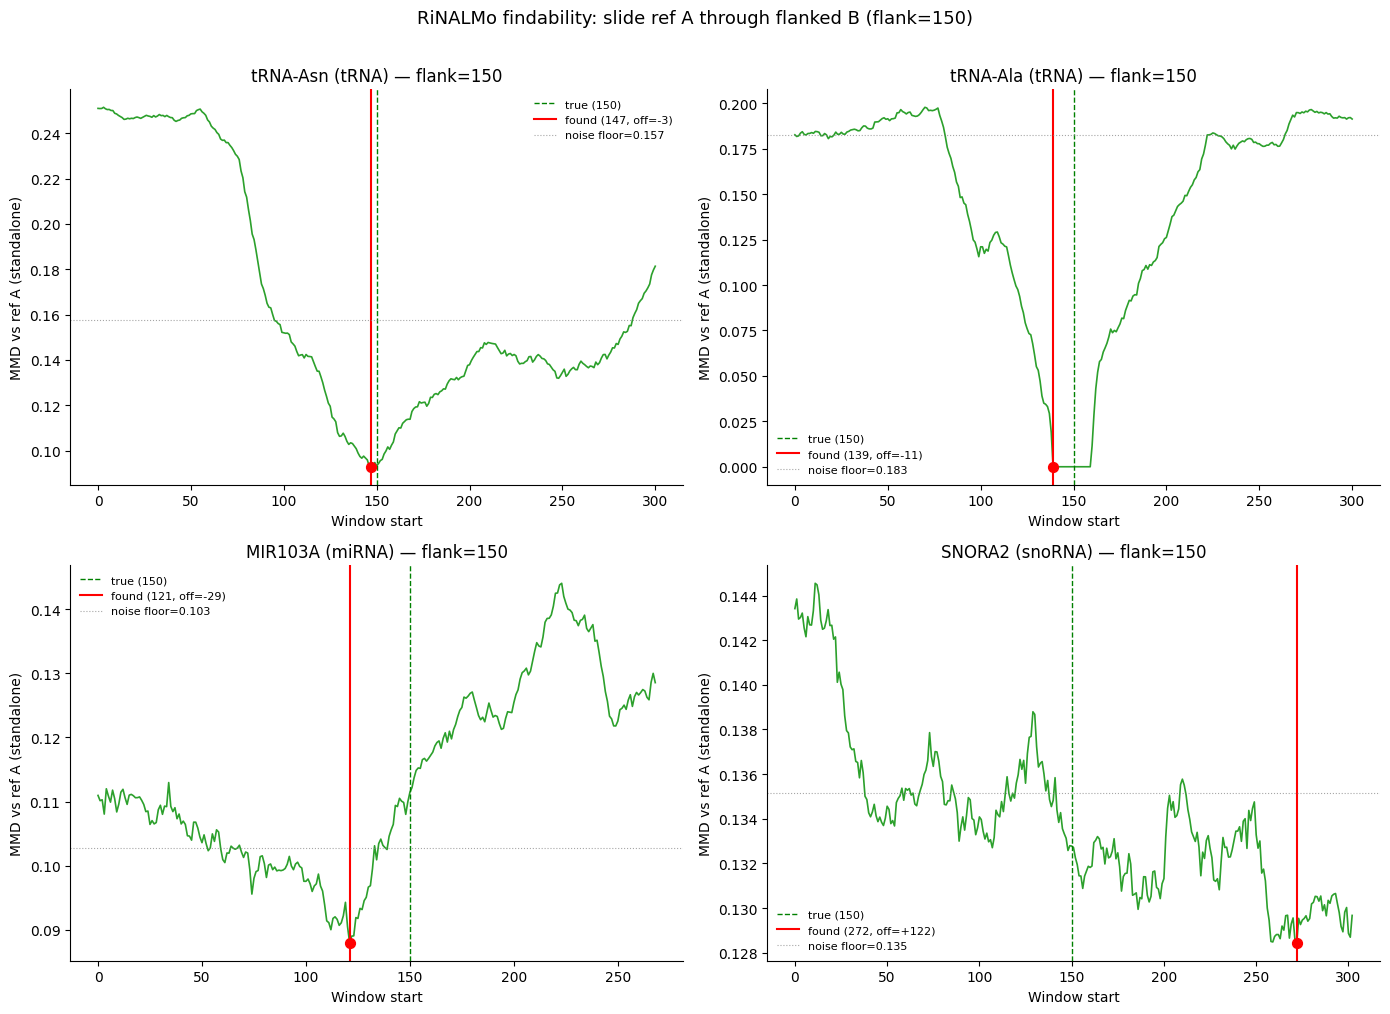

In [5]:
# Plot MMD profiles for each pair at flank=150
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, p in enumerate(pair_data):
    ax = axes[idx // 2][idx % 2]
    f = 150
    profile = find_profiles[(p["name"], f)]
    row = find_df[(find_df.pair == p["name"]) & (find_df.flank == f)].iloc[0]

    ax.plot(range(len(profile)), profile, color="#2ca02c", lw=1.2)
    ax.axvline(row["true_start"], color="green", ls="--", lw=1, label=f"true ({row['true_start']})")
    ax.axvline(row["found_pos"], color="red", lw=1.5, label=f"found ({row['found_pos']}, off={row['offset']:+d})")
    ax.scatter([row["found_pos"]], [row["mmd_best"]], color="red", s=50, zorder=5)
    ax.axhline(row["noise_floor"], color="grey", ls=":", lw=0.8, alpha=0.7, label=f"noise floor={row['noise_floor']:.3f}")

    ax.set_xlabel("Window start")
    ax.set_ylabel("MMD vs ref A (standalone)")
    ax.set_title(f"{p['name']} ({p['class']}) — flank={f}")
    ax.legend(fontsize=8, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("RiNALMo findability: slide ref A through flanked B (flank=150)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Findability heatmap: offset error by pair x flank size

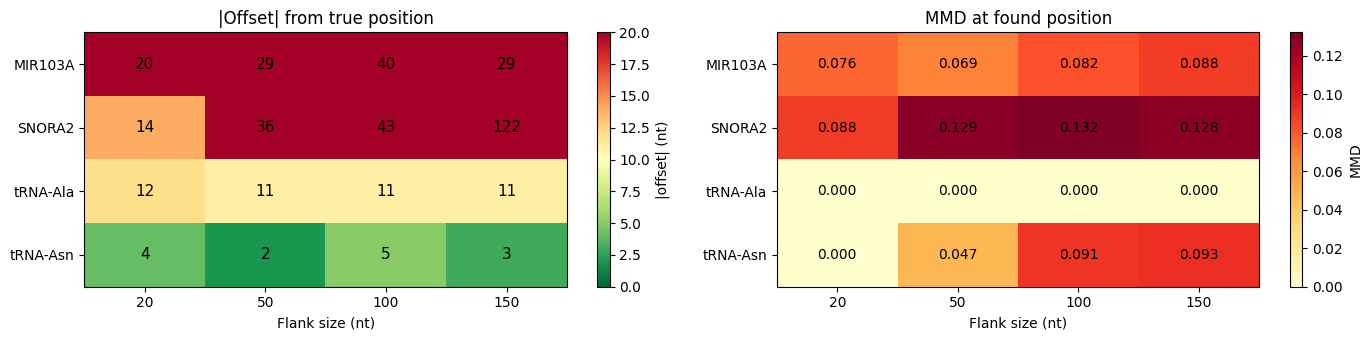

In [6]:
# Heatmap: rows = pairs, columns = flank sizes, color = |offset|
pivot_off = find_df.pivot(index="pair", columns="flank", values="offset").abs()
pivot_mmd = find_df.pivot(index="pair", columns="flank", values="mmd_best")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# Offset heatmap
ax = axes[0]
im = ax.imshow(pivot_off.values, cmap="RdYlGn_r", vmin=0, vmax=20, aspect="auto")
ax.set_xticks(range(len(FLANK_SIZES)))
ax.set_xticklabels(FLANK_SIZES)
ax.set_yticks(range(len(pivot_off.index)))
ax.set_yticklabels(pivot_off.index)
ax.set_xlabel("Flank size (nt)")
ax.set_title("|Offset| from true position")
for i in range(pivot_off.shape[0]):
    for j in range(pivot_off.shape[1]):
        ax.text(j, i, f"{int(pivot_off.values[i,j])}", ha="center", va="center", fontsize=11)
plt.colorbar(im, ax=ax, label="|offset| (nt)")

# MMD at best position
ax = axes[1]
im2 = ax.imshow(pivot_mmd.values, cmap="YlOrRd", vmin=0, aspect="auto")
ax.set_xticks(range(len(FLANK_SIZES)))
ax.set_xticklabels(FLANK_SIZES)
ax.set_yticks(range(len(pivot_mmd.index)))
ax.set_yticklabels(pivot_mmd.index)
ax.set_xlabel("Flank size (nt)")
ax.set_title("MMD at found position")
for i in range(pivot_mmd.shape[0]):
    for j in range(pivot_mmd.shape[1]):
        ax.text(j, i, f"{pivot_mmd.values[i,j]:.3f}", ha="center", va="center", fontsize=10)
plt.colorbar(im2, ax=ax, label="MMD")

plt.tight_layout()
plt.show()

## Cross-pair discrimination

Slide each ref A through ALL flanked B sequences (same and different families).
The minimum MMD should be clearly lower for the matching family.

In [7]:
# Cross-pair: for each ref A, slide through every flanked B (flank=150)
F = 150
cross_rows = []

# Pre-embed all refs and flanked Bs
ref_embs = {}
flanked_embs = {}
for p in pair_data:
    ref_embs[p["name"]] = emb(p["a_core"])
    lf = p["b_lf"][-F:] if F <= len(p["b_lf"]) else p["b_lf"]
    rf = p["b_rf"][:F] if F <= len(p["b_rf"]) else p["b_rf"]
    flanked_embs[p["name"]] = emb(lf + p["b_core"] + rf)

print(f"{'ref A':>12s} | {'target B':>12s} | {'min MMD':>8s} | {'match?':>6s}")
print("-" * 50)

for p_ref in pair_data:
    ref = ref_embs[p_ref["name"]]
    ref_len = len(p_ref["a_core"])
    for p_tgt in pair_data:
        long = flanked_embs[p_tgt["name"]]
        if len(long) < ref_len:
            continue
        n = len(long) - ref_len + 1
        mmds = [sn._compute_mmd(ref, long[i:i+ref_len]) for i in range(n)]
        min_mmd = min(mmds)
        is_match = p_ref["name"] == p_tgt["name"]
        cross_rows.append({
            "ref": p_ref["name"], "target": p_tgt["name"],
            "ref_class": p_ref["class"], "tgt_class": p_tgt["class"],
            "min_mmd": min_mmd, "same_pair": is_match,
            "same_class": p_ref["class"] == p_tgt["class"],
        })
        tag = "MATCH" if is_match else ""
        print(f"{p_ref['name']:>12s} | {p_tgt['name']:>12s} | {min_mmd:>8.4f} | {tag:>6s}")

cross_df = pd.DataFrame(cross_rows)

       ref A |     target B |  min MMD | match?
--------------------------------------------------
    tRNA-Asn |     tRNA-Asn |   0.0929 |  MATCH
    tRNA-Asn |     tRNA-Ala |   0.1010 |       
    tRNA-Asn |      MIR103A |   0.2249 |       
    tRNA-Asn |       SNORA2 |   0.2194 |       
    tRNA-Ala |     tRNA-Asn |   0.0993 |       
    tRNA-Ala |     tRNA-Ala |   0.0000 |  MATCH
    tRNA-Ala |      MIR103A |   0.1873 |       
    tRNA-Ala |       SNORA2 |   0.1824 |       
     MIR103A |     tRNA-Asn |   0.0648 |       
     MIR103A |     tRNA-Ala |   0.0896 |       
     MIR103A |      MIR103A |   0.0879 |  MATCH
     MIR103A |       SNORA2 |   0.1182 |       
      SNORA2 |     tRNA-Asn |   0.0295 |       
      SNORA2 |     tRNA-Ala |   0.0929 |       
      SNORA2 |      MIR103A |   0.1208 |       
      SNORA2 |       SNORA2 |   0.1284 |  MATCH


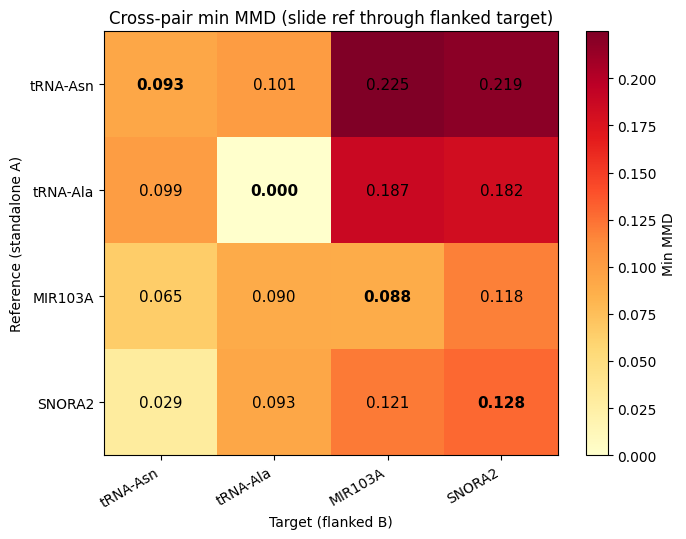

In [8]:
# Cross-pair heatmap
pivot_cross = cross_df.pivot(index="ref", columns="target", values="min_mmd")
order = [p["name"] for p in pair_data]
pivot_cross = pivot_cross.reindex(index=order, columns=order)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(pivot_cross.values, cmap="YlOrRd", vmin=0, aspect="auto")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("Target (flanked B)")
ax.set_ylabel("Reference (standalone A)")
ax.set_title("Cross-pair min MMD (slide ref through flanked target)")
for i in range(len(order)):
    for j in range(len(order)):
        v = pivot_cross.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=11,
                fontweight="bold" if i == j else "normal")
plt.colorbar(im, ax=ax, label="Min MMD")
plt.tight_layout()
plt.show()

## Summary

In [9]:
print("=" * 70)
print("RINALMO FINDABILITY SUMMARY")
print("=" * 70)

print("\n1. Baseline MMD (standalone A vs B):")
for _, r in baseline_df.iterrows():
    print(f"   {r['pair']:>10s}: MMD(A,B)={r['MMD(A,B)']:.4f}  noise={r['MMD(A,noise)']:.4f}")

print("\n2. Findability (offset from true position):")
for _, r in find_df.iterrows():
    status = "OK" if abs(r["offset"]) <= 5 else f"MISS"
    print(f"   {r['pair']:>10s} flank={r['flank']:>3.0f}: off={r['offset']:+.0f} [{status}]  "
          f"MMD={r['mmd_best']:.4f}  noise={r['noise_floor']:.4f}")

print("\n3. Cross-pair discrimination:")
matched = cross_df[cross_df.same_pair]
unmatched = cross_df[~cross_df.same_pair]
print(f"   Same-pair min MMD:  {matched['min_mmd'].mean():.4f} (mean)")
print(f"   Cross-pair min MMD: {unmatched['min_mmd'].mean():.4f} (mean)")
print(f"   Ratio: {unmatched['min_mmd'].mean() / matched['min_mmd'].mean():.1f}x" if matched['min_mmd'].mean() > 0 else "   Ratio: inf")

RINALMO FINDABILITY SUMMARY

1. Baseline MMD (standalone A vs B):
     tRNA-Asn: MMD(A,B)=0.0000  noise=0.2464
     tRNA-Ala: MMD(A,B)=0.0000  noise=0.2108
      MIR103A: MMD(A,B)=0.0910  noise=0.1145
       SNORA2: MMD(A,B)=0.0000  noise=0.1590

2. Findability (offset from true position):
     tRNA-Asn flank= 20: off=-4 [OK]  MMD=0.0000  noise=0.0596
     tRNA-Asn flank= 50: off=-2 [OK]  MMD=0.0470  noise=0.1297
     tRNA-Asn flank=100: off=-5 [OK]  MMD=0.0907  noise=0.1472
     tRNA-Asn flank=150: off=-3 [OK]  MMD=0.0929  noise=0.1574
     tRNA-Ala flank= 20: off=-12 [MISS]  MMD=0.0000  noise=0.0266
     tRNA-Ala flank= 50: off=-11 [MISS]  MMD=0.0000  noise=0.1009
     tRNA-Ala flank=100: off=-11 [MISS]  MMD=0.0000  noise=0.1632
     tRNA-Ala flank=150: off=-11 [MISS]  MMD=0.0000  noise=0.1826
      MIR103A flank= 20: off=-20 [MISS]  MMD=0.0761  noise=0.0789
      MIR103A flank= 50: off=-29 [MISS]  MMD=0.0690  noise=0.0822
      MIR103A flank=100: off=-40 [MISS]  MMD=0.0819  noise=0.